<a href="https://colab.research.google.com/github/Franco-Vallejos/Ciencia-de-datos/blob/main/Ejercicios/Segunda%20clase/01_Ej_imputacion_de_outliers_bike_buyers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ejercicio Binning, imputacion, outliers, dummies etc
El siguiente Dataset contiene detalles de 1000 potenciales compradores de bicicletas, realizaremos un análisis exploratorio del mismo, imputando las variables que correspondan.

1. ¿Cuáles de las variables contienen valores nulos?
2. ¿Está Balanceada la variable target 'Purchased Bike'?
3. Imputar los valores nulos de Gender con el valor 'X'.
4. Imputar los valores nulos y outliers de Age con la media.
5. Eliminar los registros con valor nulo en Cars.
6. Generar columnas dummy para las variables Education y Occupation.
7. Definir una estrategia de imputación para las otras variables que corresponda.
8. Finalizar el análisis exploratorio con gráficos del dataset.

In [1237]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
bike_buyers = pd.read_csv('https://raw.githubusercontent.com/pokengineer/DataScience/main/datasets/bike_buyers.csv')

In [1238]:
bike_buyers.head()

,ID,Marital Status,Gender,Income,Children,Education,Occupation,Home Owner,Cars,Commute Distance,Region,Age,Purchased Bike
0,12496,Married,Female,40000.0,1.0,Bachelors,Skilled Manual,Yes,0.0,0-1 Miles,Europe,42.0,No
1,24107,Married,Male,30000.0,3.0,Partial College,Clerical,Yes,1.0,0-1 Miles,Europe,43.0,No
2,14177,Married,Male,80000.0,5.0,Partial College,Professional,No,2.0,2-5 Miles,Europe,60.0,No
3,24381,Single,NaN,70000.0,0.0,Bachelors,Professional,Yes,1.0,5-10 Miles,Pacific,41.0,Yes
4,25597,Single,Male,30000.0,0.0,Bachelors,Clerical,No,0.0,0-1 Miles,Europe,36.0,Yes


# EJ 1

In [1239]:
nulos = bike_buyers.isnull().sum()
print(nulos)
print()
print(nulos[nulos > 0])

ID                   0
Marital Status       7
Gender              11
Income               6
Children             8
Education            0
Occupation           0
Home Owner           4
Cars                 9
Commute Distance     0
Region               0
Age                  7
Purchased Bike       0
dtype: int64

Marital Status     7
Gender            11
Income             6
Children           8
Home Owner         4
Cars               9
Age                7
dtype: int64


#### Las variables con valores nulos son: "Marital Status", "Gender", "Income", "Children", "Home Owner", "Cars" y "Age"

# EJ 2

In [1240]:
bike_buyers["Purchased Bike"].value_counts()

Purchased Bike
No     519
Yes    481
Name: count, dtype: int64

#### Balanceadisimo

# EJ 3

In [1241]:
bike_buyers["Gender"].value_counts(dropna=False) #Valores de Gender antes de la inputacion, 
                                                #incluyendo los NaN. dropna=False indica que no se 
                                                # deben eliminar los valores nulos.

Gender
Male      500
Female    489
NaN        11
Name: count, dtype: int64

In [1242]:
bike_buyers["Gender"] = bike_buyers["Gender"].fillna("X")

In [1243]:
bike_buyers["Gender"].value_counts(dropna=False)

Gender
Male      500
Female    489
X          11
Name: count, dtype: int64

# EJ 4
Para la resolucion de este ejercicio y busqueda de los outliers, voy a tener en cuenta la siguiente convencion:

Q1 = percentil 25
Q3 = percentil 75
IQR = Q3 - Q1
Se considera outlier un valor menor que Q1 - 1.5 × IQR o mayor que Q3 + 1.5 × IQR.

Un percentil indica un punto por debajo del cual se encuentra determinado porcentaje de los datos.

Q1 = percentil 25 = 35 → aproximadamente el 25% de las edades son ≤ 35.
Q3 = percentil 75 = 52 → aproximadamente el 75% de las edades son ≤ 52.
Osea que podes pensarlo como limite superior e inferior del intervalo central.

In [1244]:
bike_buyers["Age"].quantile([0.25, 0.75])   # Con un parametro de lista, quantile te devuelve un Series con los dos percentilos.

0.25    35.0
0.75    52.0
Name: Age, dtype: float64

In [1245]:
q1 = bike_buyers["Age"].quantile(0.25)    #Acá guardo individualmente los percentilos con un parametro entero.
q3 = bike_buyers["Age"].quantile(0.75)

iqr = q3 - q1
iqr

np.float64(17.0)

Y finalizando con el criterio de 1.5 × IQR

In [1246]:
limite_inferior = q1 - 1.5 * iqr    #inferior = 35 - 25.5 = 9.5

limite_superior = q3 + 1.5 * iqr    #superior = 52 + 25.5 = 77.5

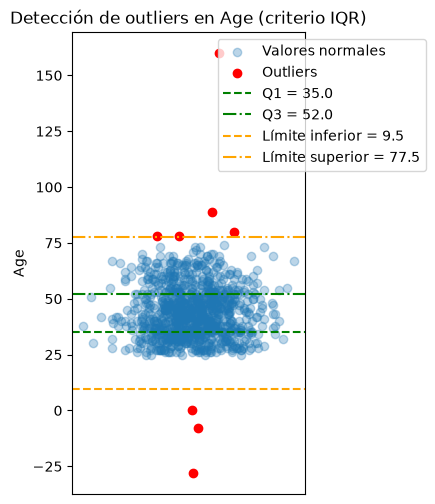

In [1247]:
# Eje X con jitter para poder ver todos los puntos sin que se superpongan
x = np.random.normal(loc=1, scale=0.04, size=len(bike_buyers))

es_outlier = (bike_buyers["Age"] < limite_inferior) | (bike_buyers["Age"] > limite_superior)

plt.figure(figsize=(3, 6))
# Puntos normales vs outliers, en colores distintos
plt.scatter(x[~es_outlier], bike_buyers["Age"][~es_outlier], alpha=0.3, label="Valores normales")
plt.scatter(x[es_outlier], bike_buyers["Age"][es_outlier], color="red", label="Outliers")

# Lineas de referencia: cuantiles y limites
plt.axhline(q1, color="green", linestyle="--", label=f"Q1 = {q1}")
plt.axhline(q3, color="green", linestyle="-.", label=f"Q3 = {q3}")
plt.axhline(limite_inferior, color="orange", linestyle="--", label=f"Límite inferior = {limite_inferior}")
plt.axhline(limite_superior, color="orange", linestyle="-.", label=f"Límite superior = {limite_superior}")

plt.title("Detección de outliers en Age (criterio IQR)")
plt.ylabel("Age")
plt.xticks([])
plt.legend(loc="upper right", bbox_to_anchor=(1.55, 1))
plt.show()

Entonces consideramos outlier cualquier edad:

Age < 9.5  o  Age > 77.5

Tambien podemos pensar outliers como puntos de referencias extremos.

Si queremos filtrar la lista con los outliers, aplicas condiciones sobre variables dentro del corchetes del dataframe:

In [1248]:
outliers = bike_buyers[
    (bike_buyers["Age"] < limite_inferior) |
    (bike_buyers["Age"] > limite_superior)
]
outliers

,ID,Marital Status,Gender,Income,Children,Education,Occupation,Home Owner,Cars,Commute Distance,Region,Age,Purchased Bike
58,25502,Married,Female,40000.0,1.0,Bachelors,Skilled Manual,Yes,0.0,0-1 Miles,Europe,-8.0,Yes
121,15922,Married,Male,150000.0,2.0,High School,Professional,Yes,4.0,0-1 Miles,Europe,160.0,No
212,20946,Single,Female,30000.0,0.0,Partial College,Clerical,No,1.0,2-5 Miles,Europe,0.0,No
250,22931,Married,Male,100000.0,5.0,Graduate Degree,Management,No,1.0,1-2 Miles,Pacific,78.0,Yes
371,22918,Single,Male,80000.0,5.0,Graduate Degree,Management,Yes,3.0,0-1 Miles,Pacific,-28.0,No
375,15628,Married,Female,40000.0,1.0,Bachelors,Skilled Manual,Yes,1.0,0-1 Miles,Europe,89.0,No
401,11555,Married,Female,40000.0,1.0,Bachelors,Clerical,Yes,0.0,0-1 Miles,Europe,80.0,No
595,18058,Single,Female,20000.0,3.0,High School,Skilled Manual,Yes,2.0,2-5 Miles,North America,78.0,No


Por otro lado, la media, asi como la mediana y la moda tienen metodos bastante directos sobre una variable objetivo:

In [1249]:
print(f"Media: {bike_buyers['Age'].mean() }")   # media
print(f"Mediana: {bike_buyers['Age'].median() }")  # mediana
print(f"Moda: {bike_buyers['Age'].mode().iloc[0]}") # moda

Media: 44.13997985901309
Mediana: 43.0
Moda: 40.0


Aclaracion: la media incluye los outliers.

Despues, recordemos que algo como "bike_buyers["Age"] > 77.5" aplica la comparacion a cada celda de la columna, devolviendo un Series con True y False por celda.

Finalmente, el elemento final para resolver esto es el metodo "loc" que recibe una condicion que se aplica a cada registro en la variable indicada. El valor que modificara cada celda (en este caso la media) NO ES UN PARAMETRO, sino que se asigna. Es como que hay una funcion del lado izquierdo, contrario a como usualmente programamos...

Podemos pensar el uso de loc como "DataFrame.loc[filas, columnas]"

In [1250]:
media = bike_buyers["Age"].mean()   # Calculamos la media

condicion = (
    bike_buyers["Age"].isna() |
    (bike_buyers["Age"] < limite_inferior) |
    (bike_buyers["Age"] > limite_superior)      # Definimos un Series de True y False que define a que registro se aplica la operacion, y a cual no
)

bike_buyers.loc[condicion, "Age"] = media       # Tenemos condicion para decir a quien le asignamos media, y "Age" para indicar columna
bike_buyers

,ID,Marital Status,Gender,Income,Children,Education,Occupation,Home Owner,Cars,Commute Distance,Region,Age,Purchased Bike
0,12496,Married,Female,40000.0,1.0,Bachelors,Skilled Manual,Yes,0.0,0-1 Miles,Europe,42.0,No
1,24107,Married,Male,30000.0,3.0,Partial College,Clerical,Yes,1.0,0-1 Miles,Europe,43.0,No
2,14177,Married,Male,80000.0,5.0,Partial College,Professional,No,2.0,2-5 Miles,Europe,60.0,No
3,24381,Single,X,70000.0,0.0,Bachelors,Professional,Yes,1.0,5-10 Miles,Pacific,41.0,Yes
4,25597,Single,Male,30000.0,0.0,Bachelors,Clerical,No,0.0,0-1 Miles,Europe,36.0,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,23731,Married,Male,60000.0,2.0,High School,Professional,Yes,2.0,2-5 Miles,North America,54.0,Yes
996,28672,Single,Male,70000.0,4.0,Graduate Degree,Professional,Yes,0.0,2-5 Miles,North America,35.0,Yes
997,11809,Married,X,60000.0,2.0,Bachelors,Skilled Manual,Yes,0.0,0-1 Miles,North America,38.0,Yes
998,19664,Single,Male,100000.0,3.0,Bachelors,Management,No,3.0,1-2 Miles,North America,38.0,No


## VERIFICACION

In [1251]:
bike_buyers["Age"].isnull().sum()   ## Cuento si sigue habiendo nulos

np.int64(0)

In [1252]:
len(bike_buyers[
    (bike_buyers["Age"] < limite_inferior) |
    (bike_buyers["Age"] > limite_superior)        # Observo registros con outliers en "Age" del dataset
])

0

# EJ 5

In [1253]:
print(f"Nulos en la columna Cars antes: {bike_buyers.isnull().sum()['Cars']}")


Nulos en la columna Cars antes: 9


In [1254]:
bike_buyers = bike_buyers[bike_buyers["Cars"].notna()]

In [1255]:
print(f'Nulos en la columna Cars después: {bike_buyers.isnull().sum()["Cars"]}')

Nulos en la columna Cars después: 0


# EJ 6

In [1256]:
bike_buyers["Education"].unique()

<StringArray>
[          'Bachelors',     'Partial College',         'High School',
 'Partial High School',     'Graduate Degree']
Length: 5, dtype: str

In [1257]:
bike_buyers["Occupation"].unique()

<StringArray>
['Skilled Manual', 'Clerical', 'Professional', 'Manual', 'Management']
Length: 5, dtype: str

In [1258]:
bike_buyers = pd.get_dummies(bike_buyers, columns=["Education"],dtype=int)

In [1259]:
bike_buyers = pd.get_dummies(bike_buyers, columns=["Occupation"],dtype=int)

In [1260]:
bike_buyers

,ID,Marital Status,Gender,Income,Children,Home Owner,Cars,Commute Distance,Region,Age,...,Education_Bachelors,Education_Graduate Degree,Education_High School,Education_Partial College,Education_Partial High School,Occupation_Clerical,Occupation_Management,Occupation_Manual,Occupation_Professional,Occupation_Skilled Manual
0,12496,Married,Female,40000.0,1.0,Yes,0.0,0-1 Miles,Europe,42.0,...,1,0,0,0,0,0,0,0,0,1
1,24107,Married,Male,30000.0,3.0,Yes,1.0,0-1 Miles,Europe,43.0,...,0,0,0,1,0,1,0,0,0,0
2,14177,Married,Male,80000.0,5.0,No,2.0,2-5 Miles,Europe,60.0,...,0,0,0,1,0,0,0,0,1,0
3,24381,Single,X,70000.0,0.0,Yes,1.0,5-10 Miles,Pacific,41.0,...,1,0,0,0,0,0,0,0,1,0
4,25597,Single,Male,30000.0,0.0,No,0.0,0-1 Miles,Europe,36.0,...,1,0,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,23731,Married,Male,60000.0,2.0,Yes,2.0,2-5 Miles,North America,54.0,...,0,0,1,0,0,0,0,0,1,0
996,28672,Single,Male,70000.0,4.0,Yes,0.0,2-5 Miles,North America,35.0,...,0,1,0,0,0,0,0,0,1,0
997,11809,Married,X,60000.0,2.0,Yes,0.0,0-1 Miles,North America,38.0,...,1,0,0,0,0,0,0,0,0,1
998,19664,Single,Male,100000.0,3.0,No,3.0,1-2 Miles,North America,38.0,...,1,0,0,0,0,0,1,0,0,0


In [1261]:
bike_buyers.columns

Index(['ID', 'Marital Status', 'Gender', 'Income', 'Children', 'Home Owner',
       'Cars', 'Commute Distance', 'Region', 'Age', 'Purchased Bike',
       'Education_Bachelors', 'Education_Graduate Degree',
       'Education_High School', 'Education_Partial College',
       'Education_Partial High School', 'Occupation_Clerical',
       'Occupation_Management', 'Occupation_Manual', 'Occupation_Professional',
       'Occupation_Skilled Manual'],
      dtype='str')

Observacion: La funcion `get_dummies` elimina las columnas sobre la que se generaron las dummies. Por lo tanto en el Dataframe de bike_buyers ya no existen las columnas "Occupation" ni "Education"

# EJ 7

Como la imputación se realiza sobre valores nulos, seria útil observar que columnas aun tienen nulos usando un sum. Esto ayuda a la toma de decisiones.

In [1262]:
bike_buyers.isnull().sum()[bike_buyers.isnull().sum() > 0]

Marital Status    7
Income            6
Children          8
Home Owner        4
dtype: int64

Por otro lado, resulta util repasar cuando hacemos imputacion por moda, media y mediana.

1. Moda → variables categóricas
Cuando los valores son categorías y no tiene sentido hacer operaciones matemáticas.

2. Media → variables numéricas cuando los valores son relativamente representativos y no hay que preocuparse de los outliers.

3. Mediana → variables numéricas cuando puede haber valores extremos. La mediana es el valor que queda en el medio al ordenar los datos.
si no conocemos la distribución y sospechamos que una variable puede tener valores extremos, la mediana es una opción más robusta.

Por lo visto en dataset hasta ahora, entre las 4 columnas podemos aplicar la siguiente logica:

Marital Status → moda, porque es categórica.

Home Owner → moda, porque es categórica (Yes/No).

Income → mediana, porque los ingresos pueden presentar valores extremos.

Children → media porque la cantidad de hijos fluctua consistentemente entre 0 a 4 hijos. Es menos propensa a outliers como sueldos.


## Imputacion : MODA - Marital Status

In [1263]:
moda = bike_buyers["Marital Status"].mode()[0]    ## Primero determinamos cual la moda o categoria mas repetida, y para ello sacamos el primer elemento del Series devuelto.

bike_buyers["Marital Status"] = bike_buyers["Marital Status"].fillna(moda)    ## Aplicamos la imputacion con el String de moda

print(moda)      # Muestra que "Married" es el más repetido

Married


## Inputacion: MODA - Home Owner

In [ ]:
moda_home_owner = bike_buyers["Home Owner"].mode()[0] #.mode() puede devolver más de un valor
#                                               si hay empate entre dos o más categorías igual
#                                               de frecuentes, .mode() devuelve un Series con 
#                                               todas ellas. Por eso hace falta [0]
bike_buyers["Home Owner"] = bike_buyers["Home Owner"].fillna(moda_home_owner)
print(f"Moda Home Owner: {moda_home_owner}")

Moda Home Owner: Yes


## Inputacion: Mediana - Income

In [1265]:
mediana_income = bike_buyers["Income"].median()
bike_buyers["Income"] = bike_buyers["Income"].fillna(mediana_income)
print(f"Mediana Income: {mediana_income}")

Mediana Income: 60000.0


## Inputacion: Media - Children

In [1266]:
media_children = bike_buyers["Children"].mean()
bike_buyers["Children"] = bike_buyers["Children"].fillna(media_children)
print(f"Media Children: {media_children}")

Media Children: 1.9043743641912512


# EJ 8

Empezamos con un un histograma de edad (Age), observando que las edades en efecto van desde los 9 a 77 años como se demostró en el EJ 4 mediante la formula de IQR.

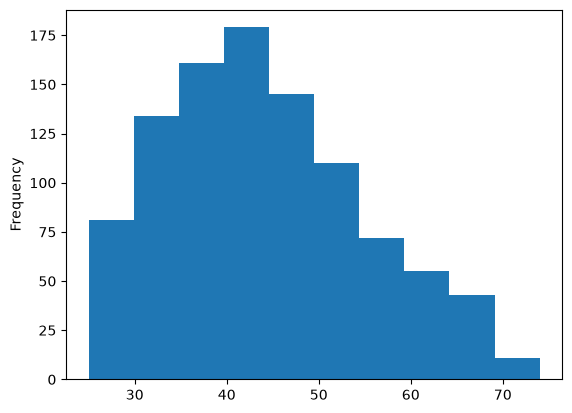

In [1267]:
import matplotlib.pyplot as plt

bike_buyers["Age"].plot(kind="hist")
plt.show()

Despues procedemos con boxplot (usualmente usado para detectar outliers) sobre los ingresos, tal como justificamos en el EJ 7 que para imputar se le ajustaba mejor la estrategia de mediana por la existencia de outliers.

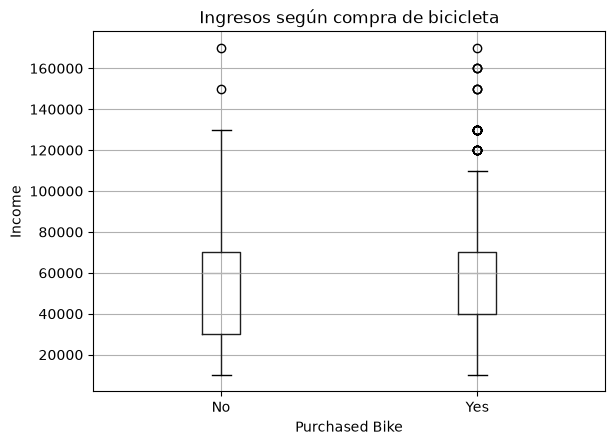

In [1268]:
bike_buyers.boxplot(column="Income", by="Purchased Bike")

plt.title("Ingresos según compra de bicicleta")
plt.suptitle("")
plt.xlabel("Purchased Bike")
plt.ylabel("Income")
plt.show()

Observacion: Que la caja de "No" sea más grande significa que el 50% central de los ingresos de quienes no compraron está más disperso.


Terminemos analizando la variable "Purchased Bike" mencionada en EJ 2 por su varianza:

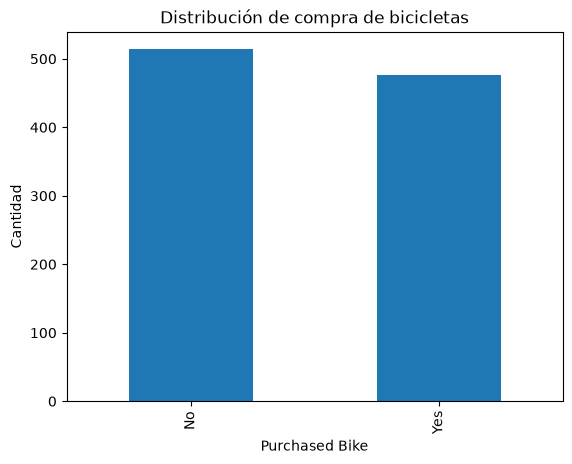

In [1269]:
bike_buyers["Purchased Bike"].value_counts().plot(kind="bar")

plt.title("Distribución de compra de bicicletas")
plt.xlabel("Purchased Bike")
plt.ylabel("Cantidad")
plt.show()

Podemos observar proporciones muy parecidas, por lo tanto una varianza despreciable.